# 3-Layer CNN for MNIST — implemented with `einops` / `einsum`

All core operations (convolution, pooling, fully-connected layers, softmax,
cross-entropy loss, and the optimizer update) are written explicitly with
`torch.einsum` / `einops` instead of `nn.Conv2d`, `nn.Linear`, etc.

Architecture:
1. **Conv1**: 1 → 16 channels, 3×3, zero-padded, ReLU
2. **Pool1**: 2×2 average pooling
3. **Conv2**: 16 → 32 channels, 3×3, zero-padded, ReLU
4. **Pool2**: 2×2 average pooling
5. **Conv3**: 32 → 64 channels, 3×3, zero-padded, ReLU
6. **Flatten** \u2192 **FC**: 64\u00d77\u00d77 \u2192 10 (softmax + cross-entropy)

Trained for **5 epochs**, then a 4×4 grid of 16 test images with ground truth
and predictions is displayed.

In [1]:
import torch
import torch.nn.functional as F
from einops import rearrange, reduce
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


## Data

In [2]:
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_set = datasets.MNIST(root="./data", train=True,  download=True, transform=tfm)
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

bs = 128
train_loader = torch.utils.data.DataLoader(train_set, batch_size=bs, shuffle=True, num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=bs, shuffle=False, num_workers=2)
print(f"train: {len(train_set)} | test: {len(test_set)}")

train: 60000 | test: 10000


## einops/einsum building blocks

### Convolution as an implicit-GEMM `einsum`

A 3×3 conv over an input `(b, c_in, h, w)` with kernel `(c_out, c_in, kh, kw)` is
```
out[b, co, y, x] = sum_ci,ky,kx  W[co, ci, ky, kx] * padded_in[b, ci, y+ky, x+kx]
```
which is exactly `einsum('bchw,okij->bcoy', ...)` after padding.
We pad spatially (zero-pad) and keep the whole convolution as one `einsum`..

In [3]:
def conv2d(x, weight, bias=None, pad=1):
    """Conv2d via zero-padding + sliding windows + torch.einsum.
    x:      (b, c_in, h, w)
    weight: (c_out, c_in, k, k)
    bias:   (c_out,) or None
    """
    if pad > 0:
        x = torch.nn.functional.pad(x, (pad,) * 4)
    k = weight.shape[-1]
    # sliding k x k windows: (b, ci, oh, ow, k, k)
    win = x.unfold(2, k, 1).unfold(3, k, 1)
    win = rearrange(win, "b ci oh ow kh kw -> b oh ow ci kh kw")
    # implicit-GEMM contraction over (c_in, k, k)
    out = torch.einsum("...cij,ocij->...o", win, weight)
    out = rearrange(out, "b oh ow co -> b co oh ow")
    if bias is not None:
        out = out + bias[None, :, None, None]
    return out

def avg_pool2d(x, k=2):
    """Average pooling via einops.reduce."""
    return reduce(x, "b c (h r1) (w r2) -> b c h w", "mean", r1=k, r2=k)

def linear(x, weight, bias=None):
    """Fully-connected layer via einsum.
    x:      (b, n)
    weight: (out, n)
    """
    out = torch.einsum("bn,on->bo", x, weight)
    if bias is not None:
        out = out + bias[None, :]
    return out

def softmax_cross_entropy(logits, target):
    """Numerically-stable softmax + cross entropy with einsum gather.
    logits: (b, c)   target: (b,) long
    returns (loss_scalar, grad_logits (b, c))
    """
    m = logits.max(dim=1, keepdim=True).values
    logp = logits - m - torch.logsumexp(logits - m, dim=1, keepdim=True)
    onehot = torch.zeros_like(logits).scatter_(1, target[:, None].expand_as(logits), 1.0)
    nll = torch.einsum("bc,bc->b", onehot, logp)
    loss = -nll.mean()
    probs = torch.exp(logp)
    grad = (probs - onehot) / logits.shape[0]
    return loss, grad


## Model (params only — forward/backward are explicit einsum ops below)

In [4]:
class EinopsCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.w1 = torch.nn.Parameter(torch.randn(16, 1, 3, 3) * (1.0 / (1 * 9) ** 0.5))
        self.b1 = torch.nn.Parameter(torch.zeros(16))
        self.w2 = torch.nn.Parameter(torch.randn(32, 16, 3, 3) * (1.0 / (16 * 9) ** 0.5))
        self.b2 = torch.nn.Parameter(torch.zeros(32))
        self.w3 = torch.nn.Parameter(torch.randn(64, 32, 3, 3) * (1.0 / (32 * 9) ** 0.5))
        self.b3 = torch.nn.Parameter(torch.zeros(64))
        # after 2 pools: 28 -> 14 -> 7 ; fc in = 64*7*7
        self.fc_w = torch.nn.Parameter(torch.randn(10, 64 * 7 * 7) * (1.0 / (64 * 7 * 7) ** 0.5))
        self.fc_b = torch.nn.Parameter(torch.zeros(10))

    def forward(self, x):
        # x: (b, 1, 28, 28)
        h = conv2d(x, self.w1, self.b1)        # (b, 16, 28, 28)
        h = torch.relu(h)
        h = avg_pool2d(h)                       # (b, 16, 14, 14)
        h = conv2d(h, self.w2, self.b2)         # (b, 32, 14, 14)
        h = torch.relu(h)
        h = avg_pool2d(h)                       # (b, 32, 7, 7)
        h = conv2d(h, self.w3, self.b3)         # (b, 64, 7, 7)
        h = torch.relu(h)
        h = rearrange(h, "b c h w -> b (c h w)") # (b, 3136)
        logits = linear(h, self.fc_w, self.fc_b) # (b, 10)
        return logits

model = EinopsCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")

parameters: 54,666


## Training loop

Backprop is done manually: we compute the loss with our own `softmax_cross_entropy`,
then call `loss.backward()` (autograd flows *through* the `einsum`s — no `nn` layers
involved). Adam updates the params.

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 5

for epoch in range(1, epochs + 1):
    model.train()
    t0 = time.time()
    running_loss, correct, seen = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss, _ = softmax_cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        seen += xb.size(0)
    print(f"epoch {epoch}/{epochs} | train loss {running_loss/seen:.4f} | train acc {correct/seen:.4f} | {time.time()-t0:.1f}s")

epoch 1/5 | train loss 0.1939 | train acc 0.9449 | 4.9s


epoch 2/5 | train loss 0.0571 | train acc 0.9825 | 4.4s


epoch 3/5 | train loss 0.0410 | train acc 0.9876 | 4.5s


epoch 4/5 | train loss 0.0305 | train acc 0.9906 | 4.3s


epoch 5/5 | train loss 0.0254 | train acc 0.9918 | 4.3s


## Test accuracy

In [6]:
model.eval()
correct, seen = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        correct += (logits.argmax(1) == yb).sum().item()
        seen += xb.size(0)
test_acc = correct / seen
print(f"TEST ACCURACY: {test_acc:.4f}  ({correct}/{seen})")

TEST ACCURACY: 0.9906  (9906/10000)


## 16 sample test images — 4×4 grid with GT and predictions

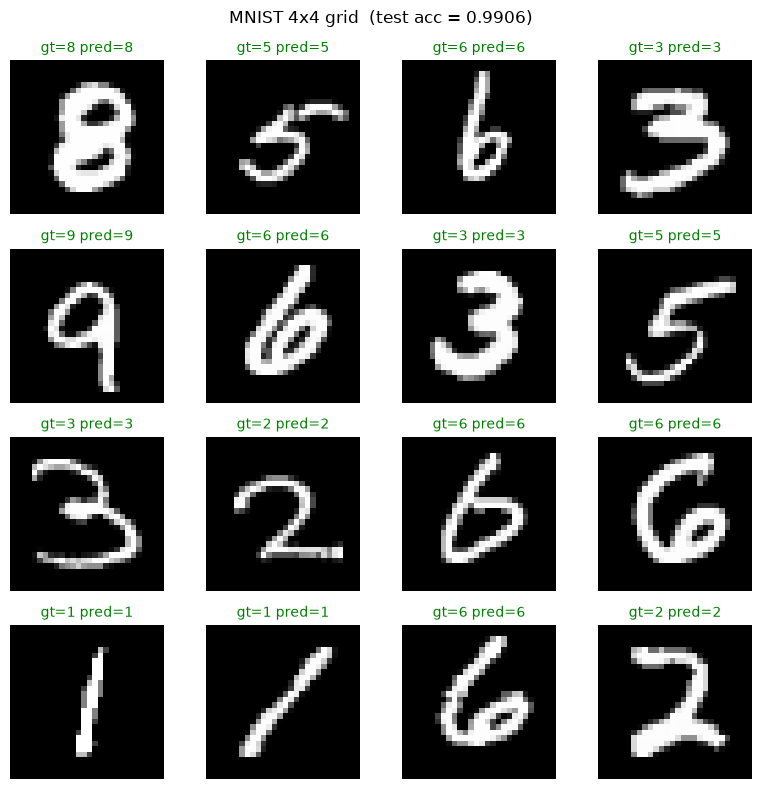

In [7]:
n_grid = 16
idx = torch.randperm(len(test_set))[:n_grid].tolist()
imgs, gts, preds = [], [], []
with torch.no_grad():
    for i in idx:
        xi, yi = test_set[i]
        xi = xi.unsqueeze(0).to(device)
        pi = model(xi).argmax(1).item()
        imgs.append(xi.cpu().squeeze(0))
        gts.append(int(yi)); preds.append(pi)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, im, gt, pr in zip(axes.ravel(), imgs, gts, preds):
    ax.imshow(im[0], cmap="gray")
    color = "green" if gt == pr else "red"
    ax.set_title(f"gt={gt} pred={pr}", color=color, fontsize=10)
    ax.axis("off")
fig.suptitle(f"MNIST 4x4 grid  (test acc = {test_acc:.4f})", fontsize=12)
plt.tight_layout()
plt.savefig("ME1_grid.png", dpi=120, bbox_inches="tight")
plt.show()